In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **1. Loading Datasets**

In [8]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [9]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [10]:
test_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


# **2. Exploratory Data Analysis (EDA)**

## **2.1 Identifying datatypes and dataset information**

### Train Dataset

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


### Test Dataset

In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


## **2.2 Performing descriptive statistical analysis on the dataset**

This part explores the descriptive statistics of the dataset, by presenting details such as, **count, mean, median, minimum value, maximum value, standard deviation, and the quartiles.**

### Train Dataset

In [13]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


### Test Dataset

In [14]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,102000.0,68.359422,27.923491,24.0,39.0,72.0,72.0,129.0
emoticon_1,102000.0,0.280078,1.043353,0.0,0.0,0.0,0.0,95.0
emoticon_2,102000.0,0.048353,0.257278,0.0,0.0,0.0,0.0,8.0
emoticon_3,102000.0,0.118902,0.480484,0.0,0.0,0.0,0.0,19.0
upvote,102000.0,2.609402,4.966033,0.0,0.0,1.0,3.0,189.0
downvote,102000.0,0.661667,1.965536,0.0,0.0,0.0,1.0,95.0
if_1,102000.0,1.903078,26.273483,0.0,0.0,0.0,4.0,1866.0
if_2,102000.0,7.956206,15.186746,4.0,4.0,6.0,10.0,1798.0


## **2.3 Number of Distinct Target Values**

In [15]:
print(f"The distinct target classes present in the dataset are {train_df['label'].unique()}.")

The distinct target classes present in the dataset are [2 0 1 3].


## **2.4 Identifying missing values in the dataset**

### Train Dataset

In [16]:
train_df.isna().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

### Test Dataset

In [17]:
test_df.isna().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [18]:
print(f"The race column has missing values amounting to {((test_df['race'].isna().sum() / test_df.shape[0])*100):.1f}% of the dataset.")
print(f"The religion column has missing values amounting to {((test_df['religion'].isna().sum() / test_df.shape[0])*100):.1f}% of the dataset.")
print(f"The gender column has missing values amounting to {((test_df['gender'].isna().sum() / test_df.shape[0])*100):.1f}% of the dataset.")

The race column has missing values amounting to 73.8% of the dataset.
The religion column has missing values amounting to 73.8% of the dataset.
The gender column has missing values amounting to 73.8% of the dataset.


# **3. Handling missing values**

In [19]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='constant', fill_value='Unknown')
train_df[['race', 'religion', 'gender']] = si.fit_transform(train_df[['race', 'religion', 'gender']])
train_df['comment'] = train_df['comment'].fillna('')
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,Unknown,Unknown,Unknown,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,Unknown,Unknown,Unknown,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,Unknown,Unknown,Unknown,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,Unknown,Unknown,Unknown,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,Unknown,Unknown,Unknown,False,"Today, the confederate flag...tomorrow, the na...",2


In [20]:
test_df[['race', 'religion', 'gender']] = si.fit_transform(test_df[['race', 'religion','gender']])
test_df['comment'] = test_df['comment'].fillna('')
test_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,Unknown,Unknown,Unknown,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,Unknown,Unknown,Unknown,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,Unknown,Unknown,Unknown,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,Unknown,Unknown,Unknown,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,Unknown,Unknown,Unknown,False,It was hard enough to get the stench out of th...


# **4. Feature Engineering**

## **4.1 Converting the 'boolean' *disability* column into integer datatype**

In [22]:
train_df['disability'] = train_df['disability'].astype(int)
test_df['disability'] = test_df['disability'].astype(int)

## **4.2 Converting the *created_date* column into separate *day, month, year* columns**

Since the feature 'created_date' holds the datetime format, it can't be useful in its original datatype for model training. Therefore, to provide appropriate data for model building, **'year', 'month'** and **'date'** of the entry has been extracted.

In [23]:
train_df['created_date'] = pd.to_datetime(train_df['created_date'], errors='coerce')
test_df['created_date'] = pd.to_datetime(test_df['created_date'], errors='coerce')

train_df['year'] = train_df['created_date'].dt.year
train_df['month'] = train_df['created_date'].dt.month
train_df['date'] = train_df['created_date'].dt.day

test_df['year'] = test_df['created_date'].dt.year
test_df['month'] = test_df['created_date'].dt.month
test_df['date'] = test_df['created_date'].dt.day

train_df = train_df.drop(columns=['created_date'])
test_df = test_df.drop(columns=['created_date'])

## **4.3 Creating a *comment_length* column**

The 'comment_length' column helps us determine the total length of the respective comment for each entry. This provides us further insight over how the length of a comment can influence a model's prediction towards category classification.

In [24]:
train_df['comment_length'] = train_df['comment'].astype(str).apply(len)
test_df['comment_length'] = test_df['comment'].astype(str).apply(len)

## **4.4 Removing URLs noise and whitespaces from the comment column**

This step was performed in order to clean the text and only retain the meaningful content in the comment column, that can prove to be influential in model predictions. URL links and unnecessary whitespaces add noise to our data, and thus removing them, makes our data cleaner and more impactful while model predictions.

In [25]:
import re
def clean_text(x):
    x = str(x)
    x = re.sub(r'http\S+|www\S+', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()
    
train_df['comment'] = train_df['comment'].apply(clean_text)
test_df['comment'] = test_df['comment'].apply(clean_text)

## **4.5 Creating new feature columns - `num_exclamations`, `num_questions`, `num_caps`, `caps_ratio`**

New feature columns such as the ones mentioned above are created to add further dimension to our dataset, and columns such as these extract meaningful influential factors that can improve our prediction's accuracy. These features help us determine how aggressive/excited a comment can be.

The following are the new columns:

* **num_exclamations:** The number of exclamation points used in a single comment.
* **num_questions:** The number of question marks used in a single comment.
* **num_caps:** The number of capital letters used in a single comment.
* **caps_ratio:** How much of the comment is written in capital letters.

In [26]:
train_df['num_exclamations'] = train_df['comment'].str.count('!')
train_df['num_questions'] = train_df['comment'].str.count(r'\?')
train_df['num_caps'] = train_df['comment'].str.count(r'[A-Z]')
train_df['caps_ratio'] = train_df['num_caps']/(train_df['comment_length']+1)

test_df['num_exclamations'] = test_df['comment'].str.count('!')
test_df['num_questions'] = test_df['comment'].str.count(r'\?')
test_df['num_caps'] = test_df['comment'].str.count(r'[A-Z]')
test_df['caps_ratio'] = test_df['num_caps']/(test_df['comment_length']+1)

In [27]:
train_df.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,...,comment,label,year,month,date,comment_length,num_exclamations,num_questions,num_caps,caps_ratio
0,73,0,0,0,0,1,0,10,Unknown,Unknown,...,She might be a bright spot for a party keou on...,2,2024,1,18,118,0,0,2,0.016807
1,39,0,0,0,6,0,0,4,Unknown,Unknown,...,"Under Alaska law, a non-tribal member is not b...",0,2024,3,24,644,0,0,9,0.013953
2,31,0,1,1,0,0,0,10,Unknown,Unknown,...,in the future please spare me your strawman dr...,2,2024,4,24,751,0,0,13,0.017287
3,39,0,0,0,5,0,0,10,Unknown,Unknown,...,"PS: That should have been ""rot"" instead of ""co...",2,2023,5,28,91,0,0,4,0.043478
4,39,0,0,0,0,0,0,10,Unknown,Unknown,...,"Today, the confederate flag...tomorrow, the na...",2,2023,9,9,254,0,0,3,0.011765


In [28]:
test_df.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,...,disability,comment,year,month,date,comment_length,num_exclamations,num_questions,num_caps,caps_ratio
0,72,2,0,0,4,1,0,10,Unknown,Unknown,...,0,Canada is being run by someone with the mental...,2024,2,8,72,0,0,1,0.013699
1,123,0,0,0,0,0,0,10,Unknown,Unknown,...,0,And your comment is left-wing drivel,2024,3,1,36,0,0,1,0.027027
2,120,0,0,0,3,0,0,4,Unknown,Unknown,...,0,,2024,2,9,69,0,0,0,0.000000
3,123,0,0,0,0,0,0,4,Unknown,Unknown,...,0,"Trump jl Blames: The Secret Service, James Com...",2024,2,17,155,1,0,23,0.147436
4,123,0,0,0,0,0,0,11,Unknown,Unknown,...,0,It was hard enough to get the stench out of th...,2024,4,24,77,0,0,4,0.051282


# **5. Data Visualisation**

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

## **5.1 Label Distribution by Number of Comments**

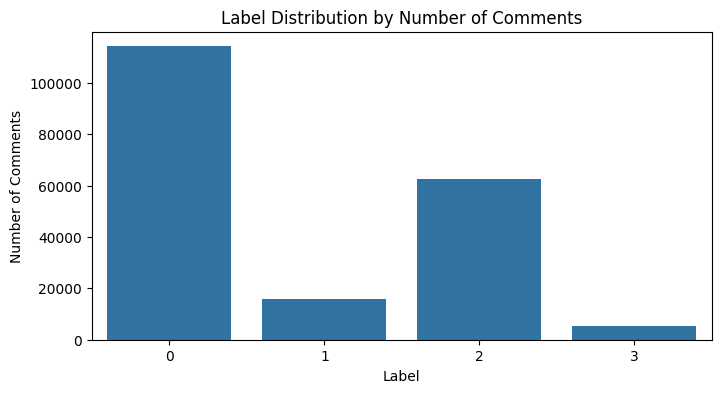

In [30]:
plt.figure(figsize=(8,4))
sns.countplot(x='label', data=train_df)
plt.title("Label Distribution by Number of Comments")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.show()

#### **Insights**

The distribution shows a **strong class imbalance**, where **Label 0** particularly dominates the dataset, followed by **Label 2**, while **Label 1** and **Label 3** are significantly underrepresented. This depicts that the most comments fall into the same category, which may bias a model towards predicting the majority class and make it harder to accurately detect the rarer but potentially more important cases represented by Labels 1 and Labels 3. Thus, using **class_weights** becomes important in this case, to avoid class imbalance in the model.

## **5.2 Distribution of Comment Length**

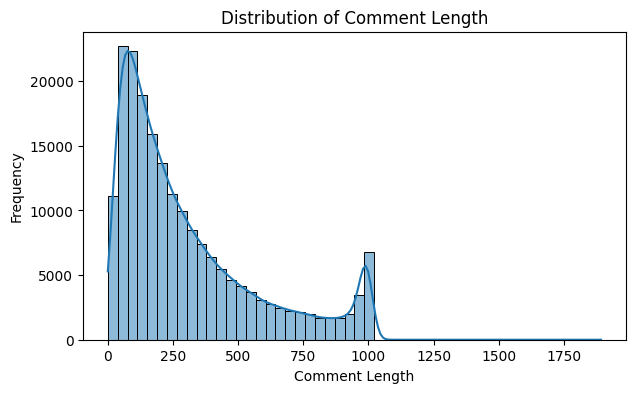

In [31]:
plt.figure(figsize=(7,4))
sns.histplot(train_df['comment_length'], bins=50, kde=True)
plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

#### **Insights**

The comment distribution is **right-skewed**, indicating that most comments are **relatively short (lying in the range of 0-250 characters)**, while a smaller number of comments are **very long** in length, creating a long tail in the distribution. This suggests that typical user interactions are brief, but occassional detailed discussions or explanations produce much longer comments, which may influence text feature extraction and model performance.

## **5.3 Most Frequent Bigrams**

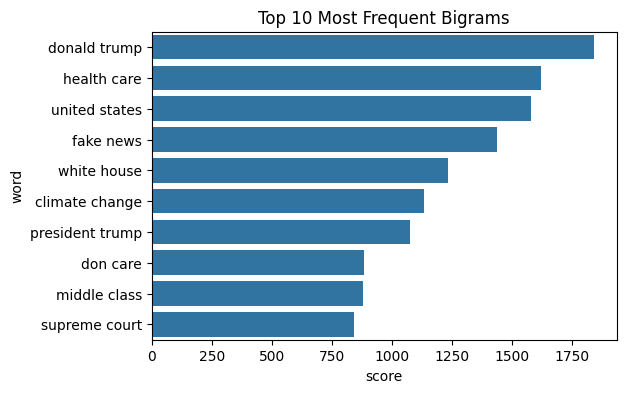

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

stopwords = text.ENGLISH_STOP_WORDS
custom_stopwords = list(stopwords.union(['just', 'like', 'think', 'know', 'good','right', 'years', 'people', 'did', 'way', 'time', 'make', 'need', 'going', 'does', 'want', 'really', 'say']))
vectorizer = CountVectorizer(stop_words=custom_stopwords, max_features=10, ngram_range=(2,2))
X = vectorizer.fit_transform(train_df['comment'].astype(str))
score = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'word':words,'score':score}).sort_values(by='score', ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x='score', y='word', data=freq_df)
plt.title("Top 10 Most Frequent Bigrams")
plt.show()

#### **Insights**

The most frequent bigrams indicate the comments frequently discuss **U.S. political topics and institutions.** Phrases such as **"White House", "Donald Trump", "Supreme Court", "Health Care"** and **"Climate Change"** suggest that the dataset contains a significant amount of political discourse related to government policies and leadership.

## **5.4 Top Words by Label**

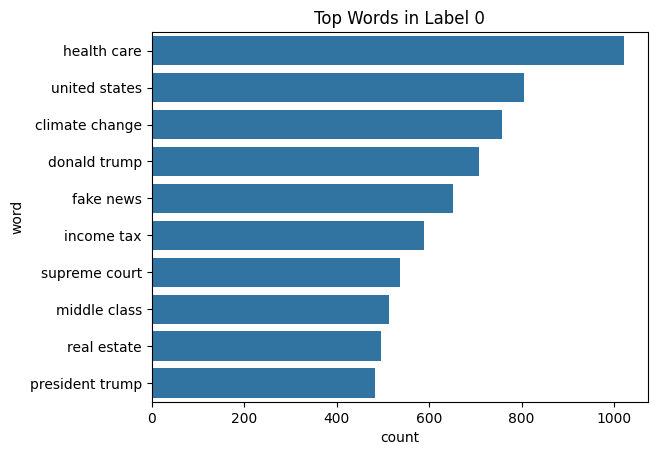

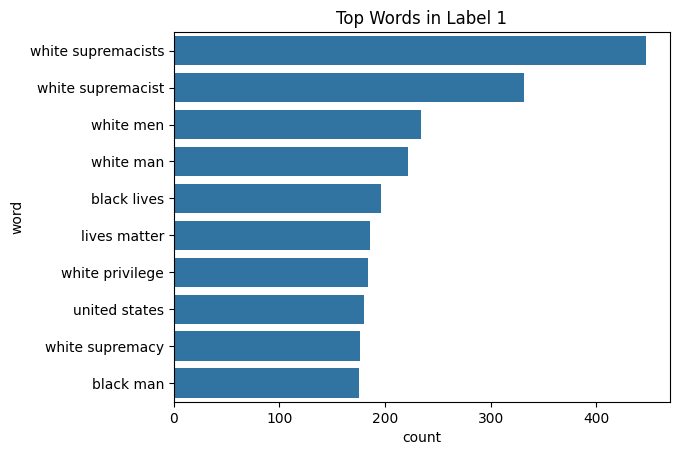

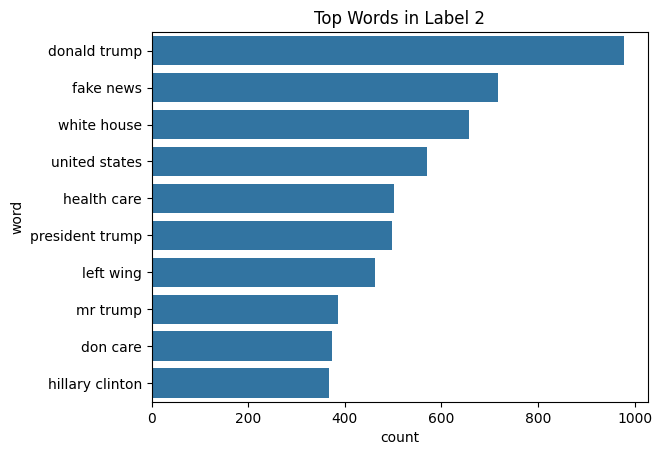

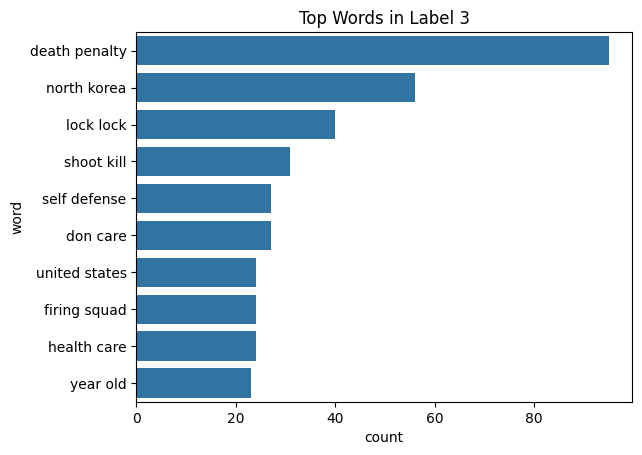

In [33]:
def top_words_by_label(df, label, n=10):
    subset = df[df['label']== label]['comment']
    vec = CountVectorizer(stop_words=custom_stopwords, max_features=1000, ngram_range=(2,2))
    X = vec.fit_transform(subset)
    word_counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    
    freq_df = pd.DataFrame({'word': words, 'count': word_counts})
    return freq_df.sort_values(by='count', ascending=False).head(n)

def plot_top_words(df, label):
    freq_df = top_words_by_label(df,label,n=10)
    plt.figure()
    sns.barplot(x='count', y='word', data=freq_df)
    plt.title(f'Top Words in Label {label}')
    plt.show()

for i in range(4):
    plot_top_words(train_df, i)

#### **Insights**

From the above plots, we can extract some very strong insights on how labelling works for different comments.

#### ***Label 0 : General and Neutral Political Discussion*** 

- Top words constitute **health care, united states, climate change, donald trump, income tax, supreme court**.
- The main focus is upon **issues, institutions & governance**.
- The discussions are mostly **policy-level**.

Thus, **Label 0** represents **neutral, informative & general political discussion**.

#### ***Label 1 : Race Related and Sensitive Social Topics*** 

- Top words constitute **white supremacist, white men, black lives, white privilege, black man**
- This label suggests a strong leaning towards **race-related & identity-focused** issues.
- The discussions are mostly about **socially sensitive movements** such as the one of **Black Lives Matter**

Thus, **Label 1** represents **socially sensitive, identity-based discussions**, which may be **polarizing** and **controversial**, but not necessarily toxic or abusive.

#### ***Label 2 : Opinionated and Political Bias Discussion*** 

- Top words constitute **donald trump, fake news, left wing, hilary clinton, don't care**
- This label suggests a clear **political bias** with quite **opinionated tone**
- Terms like **fake news & don't care** suggest that discussions could have been suggestively **argumentative** and used **dismissive language**.

Thus, **Label 2** represents **opinionated, argumentative,** or **mildly toxic** comments with **political bias**.

#### ***Label 3 : Violent & Highly Toxic Content***

- Top words constitute **death penalty, shoot kill, firing squad, self defense**
- This label suggests containing **violent & strong language**.
- The discussions might have carried **strong emotional instensity** as words directly related to **harm & punishment** were widely used.

Thus, **Label 3** represents **highly toxic, aggressive** or **violent** comments.

# **6. Scaling & Encoding Pipeline**

**Scaling**

To scale our data, numerical columns, namely, **'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_2', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'year', 'month', 'date', 'comment_length', 'num_exclamations', 'num_questions', 'num_caps', 'caps_ratio'** have been used. Scalings have been performed by StandardScaler, which standardizes the features in such a manner, that each feature has a mean of zero and a standard deviation of 1. 

**Encoding**

To encode our data, categorical columns, namely,**'race', 'religion','gender'** were encoded with the OneHotEncoder, while the text column, namely, **'comment'** was encoded with a TfidfVectorizer. OneHotEncoding ensured distribution and recognition of each unique category within a categorical column. TfidfVectorizing ensured that the text column was converted into a numerical vector, making it possible for the machine learning models to understand. 

In [35]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

x = train_df.drop(columns=['label'])
y = train_df['label']

num_col = ['post_id','emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'year', 'month', 'date', 'comment_length', 'num_exclamations', 'num_questions', 'num_caps', 'caps_ratio']
text_col = 'comment'
cat_col = ['race', 'religion', 'gender']

ct = ColumnTransformer([
    ('scale', StandardScaler(), num_col),
    ('encode', OneHotEncoder(sparse_output=True, handle_unknown='ignore'), cat_col),
    ('tfidf_word', TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=150000, sublinear_tf=True, min_df=3, max_df=0.9), text_col),
    ('tfidf_char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=80000, min_df=3), text_col)
])

# **7. Train-Test Split & Fitting the Scale-Encode Pipeline**

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

ct.fit(x_train)

x_train = ct.transform(x_train)
x_val = ct.transform(x_val)
x_test = ct.transform(test_df)

# **8. Model Building**

## **8.1 Defining Custom Class Weights**

Custom Class Weights have been defined in order to **handle class imbalance.** Handling class imbalance, often helps the macro-F1 score to boost better.

In [ ]:
class_weights={0:1, 1:2.5, 2:1.5, 3:4}

## **8.2 Model Building & Classification Reports**

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1500, random_state=42, class_weight=class_weights),
    'Stochastic Gradient Descent' : SGDClassifier(class_weight=class_weights, random_state=42, max_iter=2000),
    'Linear Support Vector Machine' : LinearSVC(max_iter=10000, class_weight=class_weights, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    results[name] = {'Macro F1' : f1}
    print(f"Model: {name}")
    print(f"F1 Score: {f1}")
    print("Classification Report")
    print("")
    print(classification_report(y_val, y_pred, zero_division=0))
    print('-' * 50)

# **9. Hyperparameter Tuning**

## **9.1 Logistic Regression**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'C' : [3, 4, 5], 
    'penalty' : ['l2'],
    'solver' : ['saga', 'lbfgs'],
    'max_iter' : [10000,12000],
    'tol' : [1e-4, 1e-5]
}

lr = RandomizedSearchCV(estimator=LogisticRegression(class_weight=class_weights), param_distributions=params, cv=2, verbose=1, n_jobs=-1, n_iter=3, random_state=42, scoring='f1_macro')
lr.fit(x_train, y_train)
lr_pred = lr.best_estimator_.predict(x_val)

print("Model : Logistic Regression (tuned)")
print(f"Macro F1 Score: {f1_score(y_val, lr_pred, average='macro')}")
print(f"Best Logistic Regression parameters: {lr.best_params_}")

# **10. Comparison of Model Performances**

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
comparison_df

As, we see from the comparison table, the best performing model is **LogisticRegression**. 

In [ ]:
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(max_iter=6000, random_state=42, class_weight=class_weights, 
                                C=3, tol=0.0001, penalty='l2', solver='saga')
best_model.fit(x_train, y_train)
predictions = best_model.predict(x_test)

# **Final Submission**

In [ ]:
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission_df = pd.DataFrame({'ID':sample['ID'], 'label': predictions})
submission_df.to_csv('submission.csv', index=False)
submission_df

# **Appendix: Milestone**

The following section contains the **5 project milestones** released on the portal, that were required to complete the project. 

## **Milestone 1 : Exploratory Data Analysis (EDA)**

In [ ]:
# Q1. What is the shape of the training dataset?
# Ans: train_df.shape

# Q2. How many columns have the object datatype in the training dataset?
# Q3. How many columns are numerical in the training dataset?
# Q4. Which column in the training dataset has boolean datatype?
# Ans : train_df.info()

# Q5. Which columns have the missing values in the training dataset?
# Ans: train_df.isna().sum()

# Q6. What percentage of dataset has the label value as 0?
# Ans: ((train_df[train_df['label'] == 0].shape[0]) / (train_df.shape[0]))*100

# Q7. What is the median of the upvote per comment?
# Ans: train_df['upvote'].median()

# Q8. Which column has the maximum numerical value in the dataset?
# Ans: train_df.select_dtypes('int64').max()

# Q9. What is the minimum value of the column if_2?
# Ans: train_df['if_2'].min()

# Q10. What is the number of distinct target classes present in the dataset?
# Ans: train_df['label'].unique()

## **Milestone 2: Scaling & Encoding**

In [ ]:
# Q1. Convert the created_date column into datetime objects. 
#     Identify the month that occurs the most number of times in the dataset.
# Ans: train_df['created_date']=pd.to_datetime(train_df['created_date'], errors='coerce')
# Ans: train_df['created_month']=train_df['created_date'].dt.month
# Ans: train_df['created_month'].value_counts()

# Q2. Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. 
#     What is the maximum value observed in this new feature across the entire dataset?
# Ans: train_df['total_emoticons']=train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']
# Ans: train_df['total_emoticons'].max()

# Q3. Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3.
# Ans: train_df[train_df['label']==3]['comment'].astype(str).apply(len).median()

# Q4. If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?
# Ans: (10-train_df['upvote'].min()) / (train_df['upvote'].max()-train_df['upvote'].min())

# Q5. What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? 
# Ans: train_df[train_df['label']==1]['comment'].apply(lambda x: len(str(x).split())).mean()

# Q6. How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
# Ans: train_df['comment'].str.contains("Trump", case=False, na=False).sum()

# Q7. Take the comment at the very first row (index 0). Remove all punctuation. Consider the following words as stop words and remove the same :  
#     ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
#     How many words are left in the text after these two operations?
# Ans : from sklearn.feature_extraction.text import TfidfVectorizer
# Ans: tfidf = TfidfVectorizer(stop_words=['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'])
# Ans: vectorized = tfidf.fit_transform([train_df.loc[0, 'comment']])
# Ans: print(len(tfidf.get_feature_names_out()))

# Q8. Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset.
# Ans: train_df['comment'].str.lower().str.split().explode().nunique()

# Q9: Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).
# How many TF-IDF features are generated using this configuration? 
# Ans: from sklearn.feature_extraction.text import TfidfVectorizer
# Ans: vect = TfidfVectorizer(stop_words = 'english', min_df = 5, ngram_range=(1,2))
# Ans: vect.fit_transform(train_df['comment'].fillna(''))
# Ans: print(len(vect.get_feature_names_out()))

## **Milestone 3: Train-Test Split**

In [ ]:
# Q1. Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. Store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. What will be the value of a + c ?
# y=train_df['label']
# X=train_df.drop(columns=['label'])
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# print(X_train.shape[0] + X_val.shape[0])

# Q2. After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it?
# X_train['created_date']=pd.to_datetime(X_train['created_date'], errors='coerce')
# X_val['created_date']=pd.to_datetime(X_val['created_date'], errors='coerce')
# X_train['month']=X_train['created_date'].dt.month
# X_val['month']=X_val['created_date'].dt.month
# X_train['year']=X_train['created_date'].dt.year
# X_val['year']=X_val['created_date'].dt.year
# X_train['day']=X_train['created_date'].dt.day
# X_val['day']=X_val['created_date'].dt.day
# print(X_train['month'].mode()[0])

# Q3. Impute the null values of categorical features with the value 'none'. Encode only religion', 'gender', 'race' features using one hot encoding, setting handle_unknown='ignore'. Make sure the output is a pandas dataframe. Let's say the shape of X_train after imputing is (a,b), what is the value of b ?
# Note: make sure to transform X_val as well using one hot encoding.
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# cat = ['race', 'religion', 'gender', 'disability', 'comment']
# encode_cols = ['race', 'religion', 'gender']
# other_cat = ['disability', 'comment']
# enc_pipe = Pipeline([
#    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
#    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])
# imp_only = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='none'))])
# imp = ColumnTransformer([('enc', enc_pipe, encode_cols),('imp', imp_only, other_cat)], 
#                        verbose_feature_names_out=False, remainder="passthrough").set_output(transform='pandas')
# X_train_transformed = imp.fit_transform(X_train)
# X_val_transformed=imp.transform(X_val)
# print(X_train_transformed.shape)

# Q4. Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix?
# Note: Please ensure to transform X_val as well.
# from sklearn.feature_extraction.text import CountVectorizer
# cv = CountVectorizer()
# X_train_comment= cv.fit_transform(X_train_transformed['comment'])
# X_val_comment = cv.transform(X_val_transformed['comment'])
# print(X_train_comment[1].sum())


# Q5. Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. What is the sum of all the 'disability values in X_train and X_val after the transformation?
# X_train_transformed['disability'] = X_train_transformed['disability'].astype(int)
# X_val_transformed['disability'] = X_val_transformed['disability'].astype(int)
# print(X_train_transformed['disability'].sum() + X_val_transformed['disability'].sum())

# Q6. Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? Ensure that you drop all datetime columns first.
# from sklearn.preprocessing import StandardScaler
# X_train_scaled = X_train_transformed.drop(columns=['comment', 'created_date'])
# ss = StandardScaler()
# ss.fit_transform(X_train_scaled)
# print(ss.n_features_in_)

# Q7. train a Multinomial Naive Bayes model on the preprocessed data. Use a pipeline if you need to. What is the macro F1 score obtained on the train dataset? 
# Note: you may train Multinomial Naive Bayes model on the preprocessed data which has been obtained from previous questions and give the answer, both ways the answers will be accepted. 
# If some feature is creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc).
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score
# nb = MultinomialNB()
# nb.fit(X_train_transformed.drop(columns=['comment', 'created_date']), y_train)
# y_pred_train = nb.predict(X_train_transformed.drop(columns=['comment', 'created_date']))
# print("Macro F1 score for train: ", f1_score(y_train, y_pred_train, average='macro'))

# Q8. What is the macro F1 score obtained on the validation dataset?
# y_pred_val = nb.predict(X_val_transformed.drop(columns=['comment', 'created_date']))
# print("Macro F1 score for val:", f1_score(y_val, y_pred_val, average='macro'))

# Q9. Create a new binary categorical column named is_weekend where Saturday and Sunday are represented as 1 and all other days as 0. After all above transformation, train MultinomialNB model. After training, use the model to predict the labels for X_train and calculate the Macro F1 score. What is the resulting score rounded to four decimal places?
# X_train_transformed['is_weekend']=(pd.to_datetime(X_train_transformed['created_date']).dt.weekday.isin([5,6]).astype(int))
# X_val_transformed['is_weekend']=(pd.to_datetime(X_val_transformed['created_date']).dt.weekday.isin([5,6]).astype(int))
# nb.fit(X_train_transformed.drop(columns=['comment', 'created_date']), y_train)
# y_pred_train = nb.predict(X_train_transformed.drop(columns=['comment', 'created_date']))
# print("Macro F1 score for train:", round(f1_score(y_train, y_pred_train, average='macro'), 4))

# Q10. What is the macro F1-score on validation set for the previous question's setup?
# y_pred_val = nb.predict(X_val_transformed.drop(columns=['comment', 'created_date']))
# print("Macro F1 score for val:", round(f1_score(y_val, y_pred_val, average='macro'), 4))

## **Milestone 4: Model Training**

#### **Q1)** Load the dataset and fill the NaN values in comment column with empty string then follow the below steps:

**A)** Split the dataset after doing above step using train_test_split into 60% train and 40% validation. Keep random_state = 2306 and set stratify to the target variable (y). After splitting, compute the class-wise counts of the training labels and validation labels using value_counts(). Before storing the counts, sort the class labels in ascending order to ensure consistent ordering. Store the resulting counts as NumPy arrays.

**B)** Load the same dataset and split it again using train_test_split, keeping all configurations the same as in Part A (60% train and 40% validation, random_state = 2306), but set stratify = None. Again, compute the sorted class-wise counts of the training labels and validation labels and store them as NumPy arrays.

**C)** Validation Distribution Difference

Using the validation label counts from Part A (stratified) and Part B (non-stratified)
Convert both validation class count arrays into proportions by dividing each count by the total number of validation samples.Make sure the class labels remain in ascending order (same order as before).

For each class, compute the absolute difference between the two proportions. Find the maximum of these absolute differences.

In [ ]:
'''# Filling the NaN values in comment column with empty string
train_df['comment'] = train_df['comment'].fillna("")
test_df['comment'] = test_df['comment'].fillna("")

# Splitting the Dataset
y = train_df['label']
x = train_df.drop(columns=['label'])

# A) Splitting with stratify = y
X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(x, y, train_size = 0.6, random_state=2306, stratify=y)
train_labels_A = y_train_A.value_counts().sort_index().to_numpy()
val_labels_A = y_val_A.value_ counts().sort_index().to_numpy()

# B) Splitting with stratify = None
X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(x, y, train_size = 0.6, random_state=2306, stratify=None)
train_labels_B = y_train_B.value_counts().sort_index().to_numpy()
val_labels_B = y_val_B.value_counts().sort_index().to_numpy()

# C) Validation Distribution Difference
val_prop_A = val_labels_A / val_labels_A.sum()
val_prop_B = val_labels_B / val_labels_B.sum()
max_diff = np.max(np.abs(val_prop_A - val_prop_B))
print("Maximum Absolute Difference: ", max_diff)'''

#### **Q2**. Use the stratified train–validation split obtained in Q1 (60% train, 40% validation, random_state=2306, stratify=y). All preprocessing objects must be fit only on the training data and then used to transform both training and validation sets.


**Step1: Column Removal. From both x_train and x_test, drop the column "created_date".**

**Step 2: Separate Text Column**

Before any tabular preprocessing.

- Extract the "comment" column:
- text_x_train = x_train["comment"]
- text_x_test = x_test["comment"]

Remove "comment" from both x_train and x_test.

**Step 3: Tabular Preprocessing**

Apply a ColumnTransformer with the following exact configuration:

- Handling categorical columns
- Categorical columns are ["race", "religion", "gender", "disability"]
- Process the above categorical columns using below techniques :
- SimpleImputer(strategy="most_frequent")
- OneHotEncoder(handle_unknown="ignore", sparse_output=True)
- Handling numerical columns
- numerical columns are ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
 "upvote", "downvote", "if_1", "if_2"]
- Process the above numerical columns using below techniques:
- SimpleImputer(strategy="mean")
- StandardScaler() (default parameters)
- ColumnTransformer Settings
- remainder="passthrough"
- Fit only on x_train
- Transform both x_train and x_test
- Store the transformed matrices as:
- x_train_tabular
- x_test_tabular

**Step 4: Text Cleaning**

Define the following function exactly:


- def normalize_text(text):
-     text = re.sub(r'http\S+|www\S+', '', text)
-     text = re.sub(r'\s+', '  ', text).strip()
-     return text

Apply it using .apply() on both text_x_train and text_x_test then store the result as text_x_train_norm, text_x_test_norm

**Step 5: TF-IDF Vectorization.**

Use: TfidfVectorizer(stop_words="english", max_features=5000) 
Fit only on text_x_train_norm and Transform both train and test text. Store as: tf_idf_train, tf_idf_test. Do not change any other parameters.

**Step 6: Combine Features**

Use: hstack to combine features in the following exact order:

- X_train_final = hstack([x_train_tabular, tf_idf_train])
- X_test_final = hstack([x_test_tabular, tf_idf_test])

The result must remain a sparse matrix.

Give the sum of all values of X_train_final, enter the answer upto 3 decimal places.
Note: handle the null values of comment column (if any) by replacing them with empty string to avoid errors.

In [ ]:
'''# Step 1: Column Removal
X_train_A = X_train_A.drop(columns=['created_date'])
X_val_A = X_val_A.drop(columns=['created_date'])

# Step 2: Separate Text Column
text_X_train_A = X_train_A['comment']
text_X_val_A = X_val_A['comment']
X_train_A = X_train_A.drop(columns=['comment'])
X_val_A = X_val_A.drop(columns=['comment'])

# Step 3: Tabular Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

cat_cols = ["race", "religion", "gender", "disability"]
num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]

cat_pipeline = Pipeline([
    ('SI', SimpleImputer(strategy='most_frequent')),
    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])
num_pipeline = Pipeline([
    ('SIN', SimpleImputer(strategy='mean')),
    ('SS', StandardScaler())
])

cat_num = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
], remainder='passthrough')

X_train_tabular_A = cat_num.fit_transform(X_train_A)
X_val_tabular_A = cat_num.transform(X_val_A)

# Step 4: Text Cleaning
import re
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text
    
text_X_train_A_norm = text_X_train_A.apply(normalize_text)
text_X_val_A_norm = text_X_val_A.apply(normalize_text)

# Step 5: TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english', max_features=5000)

tf_idf_train_A = tfidf.fit_transform(text_X_train_A_norm)
tf_idf_val_A = tfidf.transform(text_X_val_A_norm)

# Step 6: Combine All Features
from scipy.sparse import hstack

X_train_final_A = hstack([X_train_tabular_A, tf_idf_train_A])
X_val_final_A = hstack([X_val_tabular_A, tf_idf_val_A])

X_train_final_A.sum()'''

#### **For all subsequent questions (Q3 onwards), reduce the feature space using TruncatedSVD(n_components=300, random_state=2306)**

**Instructions:** 

- Fit the TruncatedSVD only on X_train_final.
- Transform both  X_train_final and X_test_final.
- Store the transformed matrices as X_train_reduced and X_test_reduced.
- Use X_train_reduced for all model training in the remaining questions. 
-  Do not refit SVD for each question. 
- Do not change n_components.

In [ ]:
# from sklearn.decomposition import TruncatedSVD
# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final_A)
# X_test_reduced = svd.transform(X_val_final_A)

#### **Q3)Use the preprocessed training data X_train_reduced.**

Perform hyperparameter tuning for a RandomForestClassifier using RandomizedSearchCV.

**Model Setup**

Initialize the model as:

- RandomForestClassifier(random_state=2306)
- Do not manually set n_estimators or max_depth here, as they will be tuned.
- Search only over the following parameter values:
    - n_estimators: [50, 100, 200]
    - max_depth: [5, 10, 15]

Do not include any other hyperparameters in the search.

RandomizedSearchCV Configuration is given below:

- n_iter = 5
- cv = 3
- random_state = 2306
- n_jobs = -1

Do not manually specify the scoring parameter (use default).
After running: randomized_search.fit(X_train_reduced, y_train) 

Retrieve the best hyperparameters using: randomized_search.best_params_ 
Return the best value of n_estimators selected by RandomizedSearchCV. Return only the integer value.

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(random_state=2306)
# params = {'n_estimators' : [50,100,200], 'max_depth':[5,10,15]}
# rs = RandomizedSearchCV(estimator=rf, param_distributions=params, n_iter=5, cv=3, random_state=2306, n_jobs=-1)
# rs.fit(X_train_reduced, y_train_A)
# rs.best_params_

#### **Q4) Use the same preprocessed training data (X_train_reduced, y_train).**

Do not modify or recompute preprocessing.

**Step 1: Train AdaBoost**

Train an AdaBoostClassifier with the following exact parameters:

- n_estimators = 50
- random_state = 2306

Use all other parameters as default. 

**Note:** Do not manually set the algorithm parameter.

Use the default behavior of AdaBoostClassifier. Fit the model on: X_train_reduced , y_train

**Step 2: Extract Estimator Errors**

After fitting, access: model.estimator_errors_
This returns a NumPy array of length 50 containing the error of each weak learner.

**Step 3: Compute Variance**

Compute the variance of the 50 estimator errors using:
np.var(model.estimator_errors_)

**Important:**
Use NumPy’s default variance computation.

**Step 4: Final Answer**

Return the variance rounded to 4 decimal places.

In [ ]:
# from sklearn.ensemble import AdaBoostClassifier
# ab = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ab.fit(X_train_reduced, y_train_A)
# print("Variance:", round(np.var(ab.estimator_errors_), 4))

#### **Q5) Train a RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306) using the preprocessed training data (X_train_reduced, y_train).**

After fitting: Extract feature_importances_.
Give the index of the feature with the maximum importance value.
Note: If multiple features share the exact same maximum importance, return the smallest index.

In [ ]:
# rfc = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rfc.fit(X_train_reduced, y_train_A)
# print("Index of the feature with maximum importance value: ", np.argmax(rfc.feature_importances_))

#### **Q6) Initialize an MLPClassifier with:**

- hidden_layer_sizes = (128, 64, 32)
- activation = "relu"
- random_state = 2306

Use the preprocessed training data (X_train_reduced , y_train). Let N be the number of input features (i.e., X_train_reduced.shape[1]). Compute the total number of weights (excluding biases) in the network. Only count connection weights between layers. Do not include bias terms.

The network structure is: 

- Input layer: N neurons
- Hidden Layer 1: 128 neurons
- Hidden Layer 2: 64 neurons
- Hidden Layer 3: 32 neurons
- Output Layer: 4 neurons

Use your actual value of N from X_train_reduced. Return the final integer count of weights.

In [ ]:
'''from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', random_state=2306)
mlp.fit(X_train_reduced, y_train_A)

#given layer sizes
N = X_train_reduced.shape[1]
h1 = 128
h2 = 64
h3 = 32
o = 4

#weights between layers
w1 = N * h1
w2 = h1 * h2
w3 = h2 * h3
w4 = h3 * o

print("Total weight: ", w1 + w2 + w3 + w4)'''

#### **Q7) Train the same MLP architecture defined in Q6 using the preprocessed training data (X_train_reduced, y_train) with the following additional parameters:**

- solver = "adam"
- max_iter = 5
- batch_size = 32
- random_state = 2306

Do not modify any other parameters (keep all others as default). After training completes (i.e., after 5 iterations), access: model.loss_

This returns the final value of the loss function after the last iteration. Return the value of model.loss_ rounded to 4 decimal places.

In [ ]:
# mlp_clf = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', random_state=2306, solver='adam', batch_size=32, max_iter=5)
# mlp_clf.fit(X_train_reduced, y_train_A)
# print("Final value of loss function after the last iteration:",round(mlp_clf.loss_, 4))

#### **Q8) Train two MLPs using the preprocessed training data (X_train_reduced, y_train) with hidden_layer_sizes=(100,), max_iter=5, and random_state=2306. use default values for other parameters unless specified.**

- Model A: alpha=0.0001 (Default)
- Model B: alpha=1.0 (Strong Regularization)

Calculate the Macro F1 Score for both on the training set. What is the absolute difference between both the scores? (answer upto 4 decimal places).

In [ ]:
'''from sklearn.metrics import f1_score

model_A = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=0.0001)
model_B = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=1.0)

model_A.fit(X_train_reduced, y_train_A)
f1_A = f1_score(y_train_A, model_A.predict(X_train_reduced), average='macro')

model_B.fit(X_train_reduced, y_train_A)
f1_B = f1_score(y_train_A, model_B.predict(X_train_reduced), average='macro')

print("Absolute Difference between Macro F1 Score of Model A & Model B:", round(abs(f1_A - f1_B), 4))'''

#### **Q9) Training the MLP model as per Q7, generate a confusion matrix for the validation set.**

What is the sum of the off-diagonal elements (representing the total number of misclassified instances) divided by the total number of samples in the validation set? (Round to 4 decimal places). 


In [ ]:
'''from sklearn.metrics import confusion_matrix
mlp_clf = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', random_state=2306, solver='adam', batch_size=32, max_iter=5)
mlp_clf.fit(X_train_reduced, y_train_A)

cm = confusion_matrix(y_val_A, mlp_clf.predict(X_test_reduced))
misclassified = cm.sum() - np.trace(cm)
total = cm.sum()
print(round(misclassified/total, 4))'''

## **Milestone 5: Hyperparameter Tuning**

#### **Common Instructions**

You are given two datasets:

- **Training dataset: df(full training data)**
- **Test dataset: test_df(test data)**
  
**Note:** (we are not going to use test_df anywhere in below questions, but in project you will be required to process the test data as well, Due to this reason we have given task to perform preprocessing in test data given to you in competition as well.)

The target variable for the training dataset(df) is y.(extract it from training data and store it as y then drop the target column from training data) Your task is to preprocess the data so that it can be used for model training.

**Step 1: Datetime Feature Engineering**

For both df and test_df: Convert the feature created_date to datetime format using pd.to_datetime(). Extract the following features from created_date: **year, month, hour**. Add these as new features. After extracting these features, drop the original created_date feature.

**Step 2: Handle Missing Values**

Perform the following preprocessing for both datasets (df and test_df):

**Categorical Features**

- Fill missing values with "Unknown" for the following features: race, religion, gender
- **Text Feature:** Replace missing values in the comment feature with an empty string "".
- **Boolean Feature:** Convert the disability feature to integer type using .astype(int).


**Step 3: Feature Transformation using ColumnTransformer**

Use ColumnTransformer to process the features as follows.

- **Text Feature**
      - Apply: TfidfVectorizer(stop_words="english", max_features=5000) to the feature: comment
- **Categorical Features**
      - Apply: OneHotEncoder(drop="first", handle_unknown="ignore") to the following features:["race", "religion", "gender"]
- **Remaining features:**
      - All remaining features should be passed through unchanged using: remainder="passthrough"

This will keep numeric features such as: *year, month, hour, disability and other numeric features*

**Step 4: Transform the Data**

Fit the ColumnTransformer only on the training dataset (df). Transform both datasets. Store the results as:

X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

**Step 5: Create Train–Validation Split**

- Split the training features and labels(X,y) into training and validation sets using: train_test_split with the following parameters: test_size = 0.2, random_state = 42
- Store the outputs as: X_train, X_val, y_train, y_val

Final Output: After completing all steps, you should have the following variables ready for model training:
X_train, X_val, y_train, y_val, X_test

Use this processed data for all the questions below.

In [ ]:
'''df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
df_test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

y = df['label']
X = df.drop(columns=['label'])

# Step 1: Datetime Feature Engineering
X['created_date'] = pd.to_datetime(X['created_date'], errors='coerce')
df_test['created_date'] = pd.to_datetime(df_test['created_date'], errors='coerce')

X['year'] = X['created_date'].dt.year
X['month'] = X['created_date'].dt.month
X['hour'] = X['created_date'].dt.month
df_test['year'] = df_test['created_date'].dt.year
df_test['month'] = df_test['created_date'].dt.month
df_test['hour'] = df_test['created_date'].dt.hour

X = X.drop(columns=['created_date'])
df_test = df_test.drop(columns=['created_date'])

# Step 2: Handle Missing Values
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='constant', fill_value='constant')
df[['race', 'religion', 'gender']] = si.fit_transform(df[['race', 'religion', 'gender']])
df_test[['race', 'religion', 'gender']] = si.fit_transform(df_test[['race', 'religion', 'gender']])

X['comment'] = X['comment'].fillna('')
df_test['comment'] = df_test['comment'].fillna('')

X['disability'] = X['disability'].astype(int)
df_test['disability'] = df_test['disability'].astype(int)

# Step 3: Feature Transformation using ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([
    ('tfidf', TfidfVectorizer(stop_words="english", max_features=5000), 'comment'),
    ('ohe', OneHotEncoder(drop="first", handle_unknown="ignore"), ['race', 'religion', 'gender']),
], remainder='passthrough')

# Step 4: Transform the Data
X = ct.fit_transform(X)
X_test = ct.transform(df_test)

# Step 5: Create Train–Validation Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)'''

In [ ]:
'''# Q2. What are the number of features in X_train?
print("Number of features in X_train: ", X_train.shape[1])

# Q3. What are the number of features in  X_val?
print("Number of features in X_val: ", X_val.shape[1])

# Q4. Train a Multinomial Naive Bayes model using the preprocessed data X_train,y_train. Generate predictions on the validation dataset (X_val,y_val) and evaluate the model using accuracy score. What validation accuracy (using X_val, y_val) does the Naive Bayes model achieve? (Round the answer to 3 decimal places.)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

mnb=MultinomialNB()
mnb.fit(X_train, y_train)
mnb_pred = mnb.predict(X_val)
print("Validation Accuracy: ", round(accuracy_score(y_val, mnb_pred), 3))

# Q5. What is the precision score for the label 3 from the classification report after performing the Multinomial Naive Bayes on validation set (X_val, y_val)? (Round the answer to 2 decimal places.)
from sklearn.metrics import classification_report
print("Classification Report to find precision for Label 3: ")
print(classification_report(y_val, mnb_pred, zero_division=0))

# Q6. Train a Logistic Regression model using the training dataset with the following parameters: max_iter = 500, random_state = 42 Generate predictions on the validation dataset (X_val, y_val) and compute the accuracy score. What validation accuracy does the Logistic Regression model achieve? (Round the answer to 3 decimal places.)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred=lr.predict(X_val)
print("Validation Accuracy: ", round(accuracy_score(y_val, lr_pred), 3))

# Q7. What training accuracy does the Logistic Regression model achieve? use X_train, y_train to calculate it. (Round the answer to 3 decimal places.)
lr_predt = lr.predict(X_train)
print("Training Accuracy: ", round(accuracy_score(y_train, lr_predt), 3))

# Q8. What is the precision score for the label 1 from the classification report after performing the Logistic regression on  validation set (use X_val, y_val)? (Round the answer to 2 decimal places.)
print("Classification Report to find precision for Label 1: ")
print(classification_report(y_val, lr_pred))

# Q9. Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV with 3-fold cross-validation. Tune the parameter C using the values 0.1, 1, and 10, and use the liblinear solver. Select the best model from GridSearch and evaluate it on the validation dataset. Which value of C out of 0.1, 1, 10 produces the best model?
from sklearn.model_selection import GridSearchCV
params = {'C':[0.1, 1, 10], 'solver':['liblinear']}

lrg = GridSearchCV(LogisticRegression(), param_grid=params, cv = 3)
lrg.fit(X_train, y_train)
y_pred = lrg.best_estimator_.predict(X_val)
print("Best value of C: ", lrg.best_params_['C'])

# Q10) What validation accuracy do you obtain after hyperparameter tuning? (Round the answer to 2 decimal places.)
print("Validation Accuracy: ", round(accuracy_score(y_val, y_pred), 2))'''